In [1]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds
import os
import gc
import time
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier, XGBRegressor

In [2]:
# ---- PATHS ----
subsampled_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_subsampled_spatial.parquet"
full_data_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_dataset.parquet"
reference_raster = r"D:\\Important\\Semester\\Semester X\\MTP\\Raw data\\landslide_distance.tif"
output_folder = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI"

In [3]:
# ---- DEFINE COLUMNS ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]

In [4]:
# ---- LOAD SUBSAMPLED DATA FOR TRAINING ----
print("Loading subsampled spatial dataset for training...")
df_sub = pd.read_parquet(subsampled_path)
df_sub["lulc"] = df_sub["lulc"].astype(np.int8)

train = df_sub[df_sub["split"] == "train"]
X_train = train[feature_cols]
Y_train_cls = train["lsi_classified"].astype(int)
Y_train_reg = train["lsi_continuous"]

print(f"Training data: {X_train.shape}")

Loading subsampled spatial dataset for training...
Training data: (699998, 11)


In [5]:
# ---- RETRAIN XGBOOST CLASSIFIER ----
print("\nTraining XGBoost Classifier...")
xgb_cls = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)
xgb_cls.fit(X_train, Y_train_cls - 1)
print("  Classifier trained.")


Training XGBoost Classifier...
  Classifier trained.


In [6]:
# ---- RETRAIN XGBOOST REGRESSOR ----
print("Training XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_reg.fit(X_train, Y_train_reg)
print("  Regressor trained.")

# ---- FREE TRAINING DATA ----
del df_sub, train, X_train, Y_train_cls, Y_train_reg
gc.collect()

Training XGBoost Regressor...
  Regressor trained.


28

In [7]:
# ---- GET RASTER METADATA FROM REFERENCE ----
with rasterio.open(reference_raster) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_width = src.width
    raster_height = src.height
    raster_nodata = src.nodata

print(f"\nReference raster metadata:")
print(f"  CRS: {raster_crs}")
print(f"  Dimensions: {raster_width} x {raster_height}")
print(f"  Transform: {raster_transform}")

print("\n✓ Models trained and raster metadata loaded.")


Reference raster metadata:
  CRS: EPSG:32643
  Dimensions: 12545 x 10553
  Transform: | 10.00, 0.00, 690010.00|
| 0.00,-10.00, 3512100.94|
| 0.00, 0.00, 1.00|

✓ Models trained and raster metadata loaded.


In [8]:
# ---- LOAD FULL DATASET ----
print("Loading full dataset...")
df_full = pd.read_parquet(full_data_path)
df_full["lulc"] = df_full["lulc"].astype(np.int8)
print(f"Full dataset: {df_full.shape}")

# ---- EXTRACT COORDINATES AND FEATURES ----
pixel_rows = df_full["pixel_row"].values
pixel_cols = df_full["pixel_col"].values
X_full = df_full[feature_cols]

print(f"Pixels to predict: {len(X_full):,}")

# ---- PREDICT IN CHUNKS (memory safe) ----
chunk_size = 5_000_000
n_chunks = int(np.ceil(len(X_full) / chunk_size))

print(f"\nPredicting in {n_chunks} chunks of {chunk_size:,}...")

pred_cls_all = np.zeros(len(X_full), dtype=np.int8)
pred_reg_all = np.zeros(len(X_full), dtype=np.float32)

for i in range(n_chunks):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, len(X_full))
    
    chunk = X_full.iloc[start:end]
    
    # Classification prediction (0-indexed → add 1)
    pred_cls_all[start:end] = (xgb_cls.predict(chunk) + 1).astype(np.int8)
    
    # Regression prediction
    pred_reg_all[start:end] = xgb_reg.predict(chunk).astype(np.float32)
    
    print(f"  Chunk {i+1}/{n_chunks}: rows {start:,} to {end:,} done")

print(f"\nClassification predictions: {np.unique(pred_cls_all)} (classes)")
print(f"Regression predictions: {pred_reg_all.min():.4f} to {pred_reg_all.max():.4f}")

# ---- FREE FULL DATAFRAME ----
del X_full, df_full
gc.collect()

Loading full dataset...
Full dataset: (51423700, 15)
Pixels to predict: 51,423,700

Predicting in 11 chunks of 5,000,000...
  Chunk 1/11: rows 0 to 5,000,000 done
  Chunk 2/11: rows 5,000,000 to 10,000,000 done
  Chunk 3/11: rows 10,000,000 to 15,000,000 done
  Chunk 4/11: rows 15,000,000 to 20,000,000 done
  Chunk 5/11: rows 20,000,000 to 25,000,000 done
  Chunk 6/11: rows 25,000,000 to 30,000,000 done
  Chunk 7/11: rows 30,000,000 to 35,000,000 done
  Chunk 8/11: rows 35,000,000 to 40,000,000 done
  Chunk 9/11: rows 40,000,000 to 45,000,000 done
  Chunk 10/11: rows 45,000,000 to 50,000,000 done
  Chunk 11/11: rows 50,000,000 to 51,423,700 done

Classification predictions: [1 2 3 4 5] (classes)
Regression predictions: 2.0430 to 5.0112


175

In [9]:
# ---- RECONSTRUCT 2D RASTERS ----
print("\nReconstructing raster grids...")

# Initialize with NoData
cls_raster = np.full((raster_height, raster_width), 0, dtype=np.int8)
reg_raster = np.full((raster_height, raster_width), np.nan, dtype=np.float32)

# Place predictions at correct pixel locations
cls_raster[pixel_rows, pixel_cols] = pred_cls_all
reg_raster[pixel_rows, pixel_cols] = pred_reg_all

print(f"  Classification raster: {cls_raster.shape}, unique values: {np.unique(cls_raster[cls_raster > 0])}")
print(f"  Regression raster: {reg_raster.shape}, range: {np.nanmin(reg_raster):.4f} to {np.nanmax(reg_raster):.4f}")

# ---- SAVE AS GEOTIFF — CLASSIFICATION MAP ----
cls_output_path = os.path.join(output_folder, "ML_suitability_classified.tif")

with rasterio.open(
    cls_output_path, 'w',
    driver='GTiff',
    height=raster_height,
    width=raster_width,
    count=1,
    dtype='int8',
    crs=raster_crs,
    transform=raster_transform,
    nodata=0
) as dst:
    dst.write(cls_raster, 1)

print(f"\n✓ Classification map saved: {cls_output_path}")
print(f"  Size: {os.path.getsize(cls_output_path) / (1024**2):.1f} MB")

# ---- SAVE AS GEOTIFF — REGRESSION MAP ----
reg_output_path = os.path.join(output_folder, "ML_suitability_continuous.tif")

with rasterio.open(
    reg_output_path, 'w',
    driver='GTiff',
    height=raster_height,
    width=raster_width,
    count=1,
    dtype='float32',
    crs=raster_crs,
    transform=raster_transform,
    nodata=np.nan
) as dst:
    dst.write(reg_raster, 1)

print(f"✓ Regression map saved: {reg_output_path}")
print(f"  Size: {os.path.getsize(reg_output_path) / (1024**2):.1f} MB")

# ---- FREE MEMORY ----
del cls_raster, reg_raster, pred_cls_all, pred_reg_all, pixel_rows, pixel_cols
gc.collect()

print("\n✓ Both suitability maps generated successfully.")
print("Load these in QGIS to visualize alongside the MCDA LSI maps.")



Reconstructing raster grids...
  Classification raster: (10553, 12545), unique values: [1 2 3 4 5]
  Regression raster: (10553, 12545), range: 2.0430 to 5.0112

✓ Classification map saved: D:\\Important\\Semester\\Semester X\\MTP\\LSI\ML_suitability_classified.tif
  Size: 126.3 MB
✓ Regression map saved: D:\\Important\\Semester\\Semester X\\MTP\\LSI\ML_suitability_continuous.tif
  Size: 505.1 MB

✓ Both suitability maps generated successfully.
Load these in QGIS to visualize alongside the MCDA LSI maps.


### Step 8: Spatial Comparison — ML Map vs MCDA Map
#### This is your core research contribution. We compare the two maps pixel-by-pixel.

In [10]:
# ---- LOAD FULL DATASET WITH BOTH PREDICTIONS AND ACTUALS ----
print("Loading full dataset for comparison...")
df_full = pd.read_parquet(full_data_path)
df_full["lulc"] = df_full["lulc"].astype(np.int8)

# ---- MCDA VALUES (already in dataset) ----
mcda_cls = df_full["lsi_classified"].astype(int).values
mcda_reg = df_full["lsi_continuous"].values
pixel_rows = df_full["pixel_row"].values
pixel_cols = df_full["pixel_col"].values

# ---- ML PREDICTIONS (predict again on full data) ----
print("Predicting on full dataset...")
X_full = df_full[feature_cols]

chunk_size = 5_000_000
n_chunks = int(np.ceil(len(X_full) / chunk_size))

ml_cls = np.zeros(len(X_full), dtype=np.int8)
ml_reg = np.zeros(len(X_full), dtype=np.float32)

for i in range(n_chunks):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, len(X_full))
    chunk = X_full.iloc[start:end]
    ml_cls[start:end] = (xgb_cls.predict(chunk) + 1).astype(np.int8)
    ml_reg[start:end] = xgb_reg.predict(chunk).astype(np.float32)
    print(f"  Chunk {i+1}/{n_chunks} done")

del X_full
gc.collect()

Loading full dataset for comparison...
Predicting on full dataset...
  Chunk 1/11 done
  Chunk 2/11 done
  Chunk 3/11 done
  Chunk 4/11 done
  Chunk 5/11 done
  Chunk 6/11 done
  Chunk 7/11 done
  Chunk 8/11 done
  Chunk 9/11 done
  Chunk 10/11 done
  Chunk 11/11 done


175

In [11]:
# ============================================================
# CLASSIFICATION AGREEMENT ANALYSIS
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix)

print("\n" + "=" * 60)
print("PIXEL-WISE CLASSIFICATION AGREEMENT (Full Dataset)")
print("=" * 60)

overall_accuracy = accuracy_score(mcda_cls, ml_cls)
overall_kappa = cohen_kappa_score(mcda_cls, ml_cls)
overall_f1 = f1_score(mcda_cls, ml_cls, average='weighted')

print(f"\nOverall Accuracy:  {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Cohen's Kappa:     {overall_kappa:.4f}")
print(f"Weighted F1:       {overall_f1:.4f}")

class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}

print(f"\nClassification Report:")
print(classification_report(mcda_cls, ml_cls,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# ---- CONFUSION MATRIX ----
print("Confusion Matrix (rows=MCDA, cols=ML):")
cm = confusion_matrix(mcda_cls, ml_cls)
cm_df = pd.DataFrame(cm,
                      index=[f"MCDA {class_labels[i]}" for i in range(1, 6)],
                      columns=[f"ML {class_labels[i]}" for i in range(1, 6)])
print(cm_df.to_string())

# ---- PER-CLASS AGREEMENT PERCENTAGE ----
print(f"\nPer-Class Agreement:")
print(f"  {'Class':<12} {'MCDA Pixels':>12} {'ML Agrees':>12} {'Agreement %':>12}")
print("  " + "-" * 50)
for i in range(5):
    cls = i + 1
    total = cm[i].sum()
    agree = cm[i][i]
    pct = (agree / total) * 100 if total > 0 else 0
    print(f"  {class_labels[cls]:<12} {total:>12,} {agree:>12,} {pct:>11.2f}%")


PIXEL-WISE CLASSIFICATION AGREEMENT (Full Dataset)

Overall Accuracy:  0.9811 (98.11%)
Cohen's Kappa:     0.9654
Weighted F1:       0.9810

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.97      0.88      0.93   1060985
         Low       0.98      0.97      0.97  13055064
    Moderate       0.98      0.99      0.99  31455011
        High       0.99      0.97      0.98   5826106
   Very High       0.86      0.95      0.90     26534

    accuracy                           0.98  51423700
   macro avg       0.95      0.95      0.95  51423700
weighted avg       0.98      0.98      0.98  51423700

Confusion Matrix (rows=MCDA, cols=ML):
                ML Very Low    ML Low  ML Moderate  ML High  ML Very High
MCDA Very Low        938096    122884            0        0             5
MCDA Low              28589  12660466       365825        0           184
MCDA Moderate            36    192399     31185798    76368           410
MCDA High   

In [12]:
# ============================================================
# REGRESSION AGREEMENT ANALYSIS
# ============================================================
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n" + "=" * 60)
print("PIXEL-WISE REGRESSION AGREEMENT (Full Dataset)")
print("=" * 60)

r2 = r2_score(mcda_reg, ml_reg)
rmse = np.sqrt(mean_squared_error(mcda_reg, ml_reg))
mae = mean_absolute_error(mcda_reg, ml_reg)

print(f"\nR² Score:  {r2:.4f}")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")

# ---- ERROR DISTRIBUTION ----
errors = ml_reg - mcda_reg
print(f"\nPrediction Error Distribution:")
print(f"  Mean error:   {errors.mean():.4f}")
print(f"  Std error:    {errors.std():.4f}")
print(f"  Min error:    {errors.min():.4f}")
print(f"  Max error:    {errors.max():.4f}")
print(f"  |Error| < 0.1: {(np.abs(errors) < 0.1).sum():,} ({(np.abs(errors) < 0.1).mean()*100:.2f}%)")
print(f"  |Error| < 0.2: {(np.abs(errors) < 0.2).sum():,} ({(np.abs(errors) < 0.2).mean()*100:.2f}%)")
print(f"  |Error| < 0.5: {(np.abs(errors) < 0.5).sum():,} ({(np.abs(errors) < 0.5).mean()*100:.2f}%)")


PIXEL-WISE REGRESSION AGREEMENT (Full Dataset)

R² Score:  0.9949
RMSE:      0.0209
MAE:       0.0124

Prediction Error Distribution:
  Mean error:   0.0000
  Std error:    0.0209
  Min error:    -1.2821
  Max error:    1.2761
  |Error| < 0.1: 51,104,081 (99.38%)
  |Error| < 0.2: 51,417,937 (99.99%)
  |Error| < 0.5: 51,423,028 (100.00%)


In [13]:
# ============================================================
# DISAGREEMENT MAP — WHERE ML DIFFERS FROM MCDA
# ============================================================
print("\n" + "=" * 60)
print("GENERATING DISAGREEMENT MAP")
print("=" * 60)

# Difference: ML class - MCDA class
# 0 = agreement, positive = ML predicts higher, negative = ML predicts lower
diff_values = ml_cls.astype(np.int16) - mcda_cls.astype(np.int16)

print(f"\nDisagreement Distribution:")
unique_diffs, diff_counts = np.unique(diff_values, return_counts=True)
for d, c in zip(unique_diffs, diff_counts):
    pct = (c / len(diff_values)) * 100
    if d == 0:
        label = "AGREE"
    elif d > 0:
        label = f"ML +{d} class higher"
    else:
        label = f"ML {d} class lower"
    print(f"  {d:>+3d} ({label:<22}): {c:>12,} ({pct:.2f}%)")

# ---- SAVE DISAGREEMENT MAP AS GEOTIFF ----
diff_raster = np.full((raster_height, raster_width), -9, dtype=np.int8)
diff_raster[pixel_rows, pixel_cols] = diff_values.astype(np.int8)

diff_output_path = os.path.join(output_folder, "ML_vs_MCDA_disagreement.tif")

with rasterio.open(
    diff_output_path, 'w',
    driver='GTiff',
    height=raster_height,
    width=raster_width,
    count=1,
    dtype='int8',
    crs=raster_crs,
    transform=raster_transform,
    nodata=-9
) as dst:
    dst.write(diff_raster, 1)

print(f"\n✓ Disagreement map saved: {diff_output_path}")
print(f"  Size: {os.path.getsize(diff_output_path) / (1024**2):.1f} MB")
print(f"\n  Values in map:")
print(f"  -9 = NoData (outside study area)")
print(f"   0 = ML and MCDA agree")
print(f"  +1 = ML predicts 1 class higher")
print(f"  -1 = ML predicts 1 class lower")
print(f"  etc.")

# ---- CLEANUP ----
del df_full, mcda_cls, mcda_reg, ml_cls, ml_reg, diff_values, diff_raster
del pixel_rows, pixel_cols, errors
gc.collect()

print("\n✓ Step 8 complete. Load disagreement map in QGIS for visualization.")


GENERATING DISAGREEMENT MAP

Disagreement Distribution:
   -2 (ML -2 class lower     ):          145 (0.00%)
   -1 (ML -1 class lower     ):      402,105 (0.78%)
   +0 (AGREE                 ):   50,452,118 (98.11%)
   +1 (ML +1 class higher    ):      568,733 (1.11%)
   +2 (ML +2 class higher    ):          410 (0.00%)
   +3 (ML +3 class higher    ):          184 (0.00%)
   +4 (ML +4 class higher    ):            5 (0.00%)

✓ Disagreement map saved: D:\\Important\\Semester\\Semester X\\MTP\\LSI\ML_vs_MCDA_disagreement.tif
  Size: 126.3 MB

  Values in map:
  -9 = NoData (outside study area)
   0 = ML and MCDA agree
  +1 = ML predicts 1 class higher
  -1 = ML predicts 1 class lower
  etc.

✓ Step 8 complete. Load disagreement map in QGIS for visualization.


In [15]:
# ---- RESTORE COMPARISON DATA ----
print("Loading full dataset for visualizations...")
df_full = pd.read_parquet(full_data_path)
df_full["lulc"] = df_full["lulc"].astype(np.int8)

mcda_cls = df_full["lsi_classified"].astype(int).values
mcda_reg = df_full["lsi_continuous"].values

chunk_size = 5_000_000
n_chunks = int(np.ceil(len(df_full) / chunk_size))
ml_cls = np.zeros(len(df_full), dtype=np.int8)
ml_reg = np.zeros(len(df_full), dtype=np.float32)

for i in range(n_chunks):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, len(df_full))
    chunk = df_full[feature_cols].iloc[start:end]
    ml_cls[start:end] = (xgb_cls.predict(chunk) + 1).astype(np.int8)
    ml_reg[start:end] = xgb_reg.predict(chunk).astype(np.float32)

del df_full
gc.collect()
print(f"✓ Ready: {len(ml_cls):,} pixels loaded")

Loading full dataset for visualizations...
✓ Ready: 51,423,700 pixels loaded


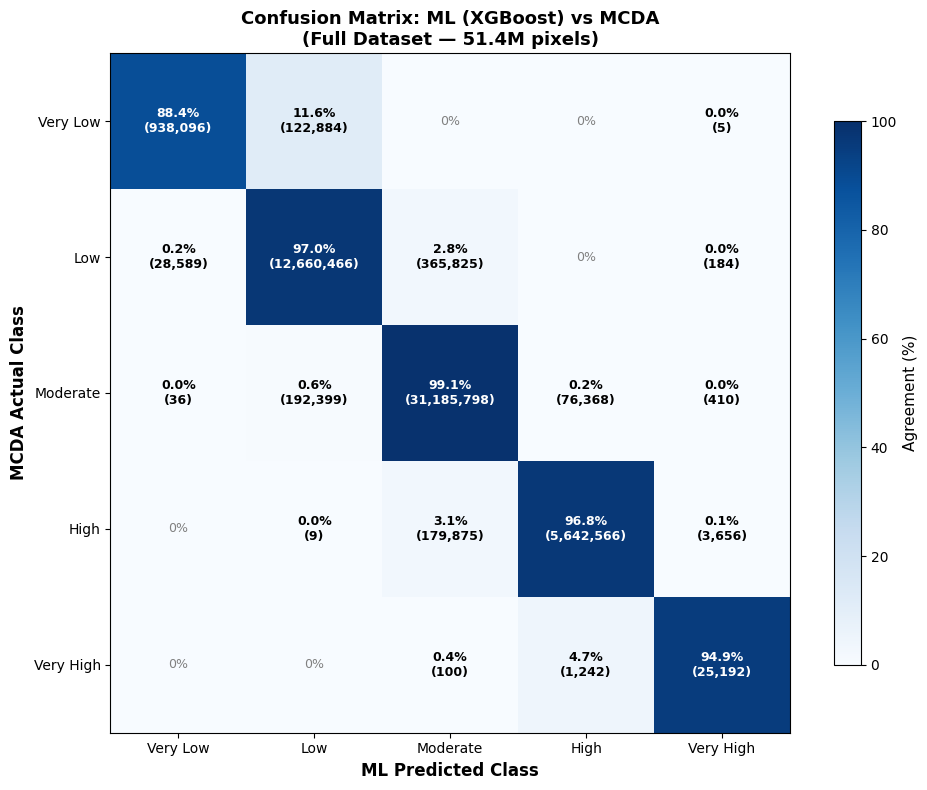

✓ Saved: viz1_confusion_matrix_heatmap.png


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---- CONFUSION MATRIX HEATMAP ----
cm = confusion_matrix(mcda_cls, ml_cls)
class_names = ["Very Low", "Low", "Moderate", "High", "Very High"]

# Convert to percentages (row-wise)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)

# Add text annotations
for i in range(5):
    for j in range(5):
        count = cm[i, j]
        pct = cm_pct[i, j]
        
        # White text on dark cells, black on light
        color = "white" if pct > 50 else "black"
        
        # Show percentage and count
        if count > 0:
            ax.text(j, i, f"{pct:.1f}%\n({count:,})",
                    ha="center", va="center", color=color, fontsize=9, fontweight="bold")
        else:
            ax.text(j, i, "0%", ha="center", va="center", color="gray", fontsize=9)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(class_names, fontsize=10)
ax.set_yticklabels(class_names, fontsize=10)
ax.set_xlabel("ML Predicted Class", fontsize=12, fontweight="bold")
ax.set_ylabel("MCDA Actual Class", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix: ML (XGBoost) vs MCDA\n(Full Dataset — 51.4M pixels)", fontsize=13, fontweight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Agreement (%)", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "viz1_confusion_matrix_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: viz1_confusion_matrix_heatmap.png")

Computing point density (this may take a moment)...


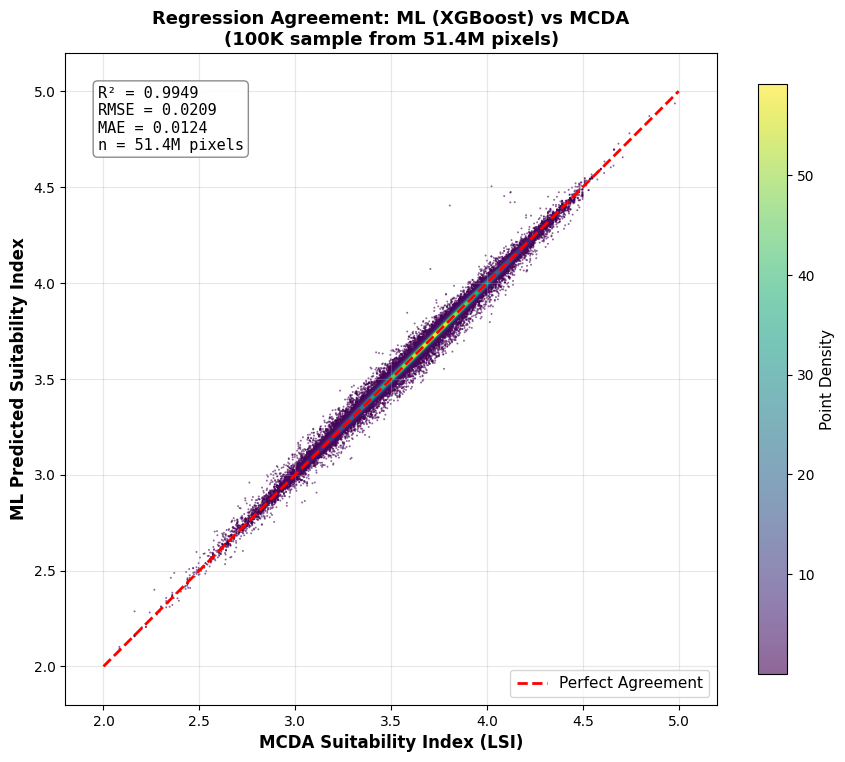

✓ Saved: viz2_regression_scatter.png


In [17]:
# ---- REGRESSION SCATTER PLOT WITH DENSITY ----
from scipy.stats import gaussian_kde

# Subsample for plotting (51M points would crash matplotlib)
np.random.seed(42)
sample_idx = np.random.choice(len(ml_reg), size=100_000, replace=False)
x_sample = mcda_reg[sample_idx]
y_sample = ml_reg[sample_idx]

# Calculate point density for coloring
print("Computing point density (this may take a moment)...")
xy = np.vstack([x_sample, y_sample])
density = gaussian_kde(xy)(xy)

# Sort by density so dense points plot on top
sort_idx = density.argsort()
x_sample = x_sample[sort_idx]
y_sample = y_sample[sort_idx]
density = density[sort_idx]

fig, ax = plt.subplots(figsize=(9, 8))

scatter = ax.scatter(x_sample, y_sample, c=density, cmap="viridis",
                     s=2, alpha=0.6, edgecolors="none")

# Perfect prediction line
ax.plot([2.0, 5.0], [2.0, 5.0], 'r--', linewidth=2, label="Perfect Agreement")

# Metrics text box
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(mcda_reg, ml_reg)
mae = mean_absolute_error(mcda_reg, ml_reg)
rmse = np.sqrt(np.mean((mcda_reg - ml_reg)**2))

textstr = f"R² = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nn = 51.4M pixels"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

ax.set_xlabel("MCDA Suitability Index (LSI)", fontsize=12, fontweight="bold")
ax.set_ylabel("ML Predicted Suitability Index", fontsize=12, fontweight="bold")
ax.set_title("Regression Agreement: ML (XGBoost) vs MCDA\n(100K sample from 51.4M pixels)", fontsize=13, fontweight="bold")
ax.set_xlim(1.8, 5.2)
ax.set_ylim(1.8, 5.2)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label("Point Density", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "viz2_regression_scatter.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: viz2_regression_scatter.png")

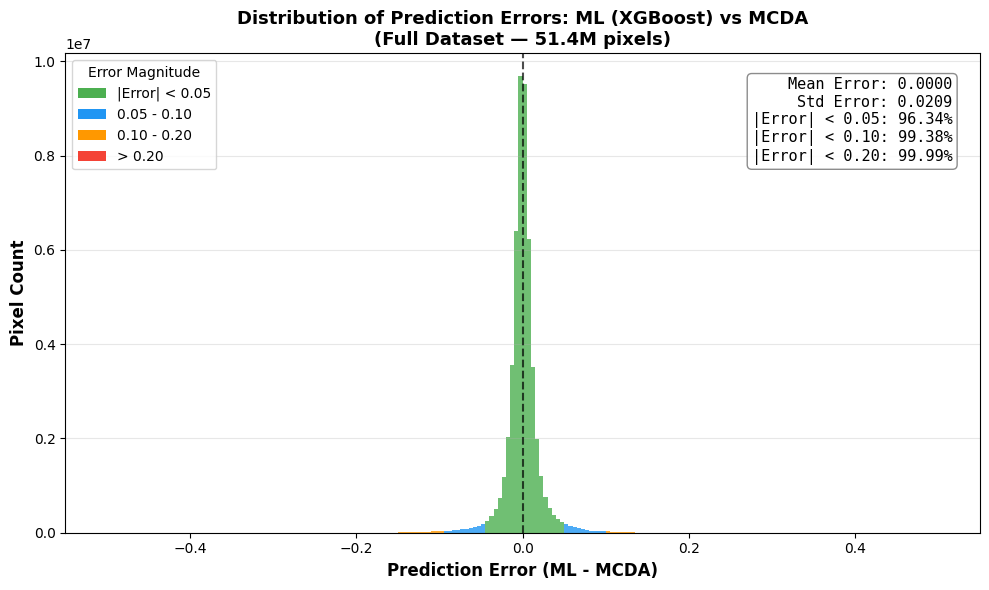

✓ Saved: viz3_error_distribution.png


In [18]:
# ---- ERROR DISTRIBUTION HISTOGRAM ----
errors = ml_reg - mcda_reg

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
counts, bins, patches = ax.hist(errors, bins=200, range=(-0.5, 0.5),
                                 color="#2196F3", alpha=0.8, edgecolor="none")

# Color bins by magnitude
for patch, left_edge in zip(patches, bins[:-1]):
    if abs(left_edge) < 0.05:
        patch.set_facecolor("#4CAF50")  # green = very small error
    elif abs(left_edge) < 0.1:
        patch.set_facecolor("#2196F3")  # blue = small error
    elif abs(left_edge) < 0.2:
        patch.set_facecolor("#FF9800")  # orange = moderate error
    else:
        patch.set_facecolor("#F44336")  # red = large error

# Vertical line at zero
ax.axvline(x=0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

# Statistics text box
within_005 = (np.abs(errors) < 0.05).mean() * 100
within_01 = (np.abs(errors) < 0.1).mean() * 100
within_02 = (np.abs(errors) < 0.2).mean() * 100

textstr = (f"Mean Error: {errors.mean():.4f}\n"
           f"Std Error: {errors.std():.4f}\n"
           f"|Error| < 0.05: {within_005:.2f}%\n"
           f"|Error| < 0.10: {within_01:.2f}%\n"
           f"|Error| < 0.20: {within_02:.2f}%")
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.97, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=props, fontfamily='monospace')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="|Error| < 0.05"),
    Patch(facecolor="#2196F3", label="0.05 - 0.10"),
    Patch(facecolor="#FF9800", label="0.10 - 0.20"),
    Patch(facecolor="#F44336", label="> 0.20")
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10, title="Error Magnitude")

ax.set_xlabel("Prediction Error (ML - MCDA)", fontsize=12, fontweight="bold")
ax.set_ylabel("Pixel Count", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Prediction Errors: ML (XGBoost) vs MCDA\n(Full Dataset — 51.4M pixels)", fontsize=13, fontweight="bold")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "viz3_error_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: viz3_error_distribution.png")

del errors

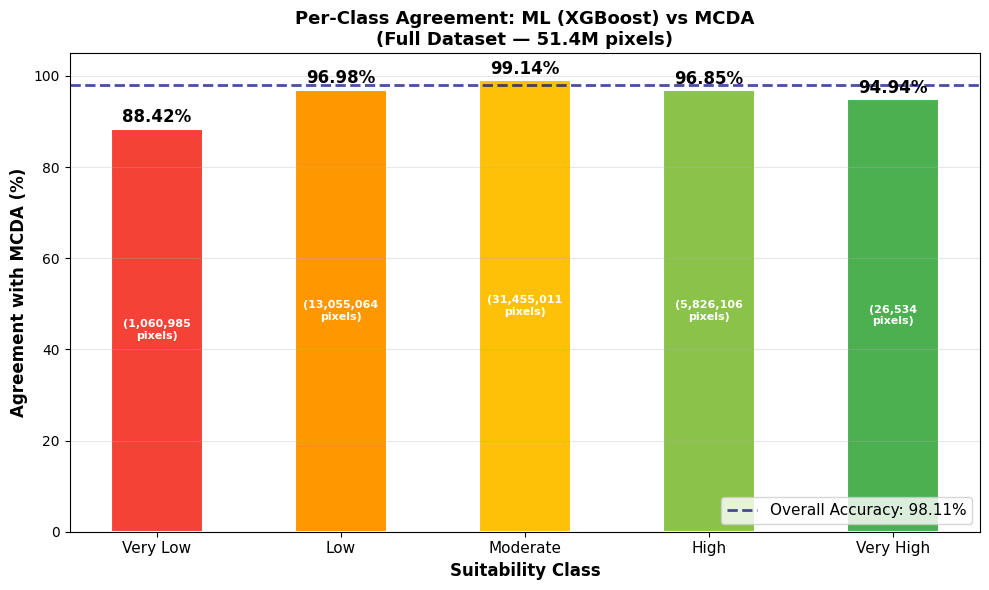

✓ Saved: viz4_class_agreement_1.png


In [21]:
# ---- CLASS-WISE AGREEMENT BAR CHART ----
cm = confusion_matrix(mcda_cls, ml_cls)
class_names = ["Very Low", "Low", "Moderate", "High", "Very High"]

# Calculate per-class metrics
agreement_pct = []
total_pixels = []
for i in range(5):
    total = cm[i].sum()
    agree = cm[i][i]
    agreement_pct.append((agree / total) * 100)
    total_pixels.append(total)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Agreement bars
x = np.arange(5)
colors = ["#F44336", "#FF9800", "#FFC107", "#8BC34A", "#4CAF50"]
bars = ax1.bar(x, agreement_pct, width=0.5, color=colors, edgecolor="white", linewidth=1.5)

# Add percentage labels on bars
for bar, pct, total in zip(bars, agreement_pct, total_pixels):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{pct:.2f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f"({total:,}\npixels)", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Overall accuracy line
overall_acc = accuracy_score(mcda_cls, ml_cls) * 100
ax1.axhline(y=overall_acc, color="navy", linewidth=2, linestyle="--", alpha=0.7,
            label=f"Overall Accuracy: {overall_acc:.2f}%")

ax1.set_xticks(x)
ax1.set_xticklabels(class_names, fontsize=11)
ax1.set_ylabel("Agreement with MCDA (%)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Suitability Class", fontsize=12, fontweight="bold")
ax1.set_title("Per-Class Agreement: ML (XGBoost) vs MCDA\n(Full Dataset — 51.4M pixels)", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 105)
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "viz4_class_agreement_1.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: viz4_class_agreement_1.png")

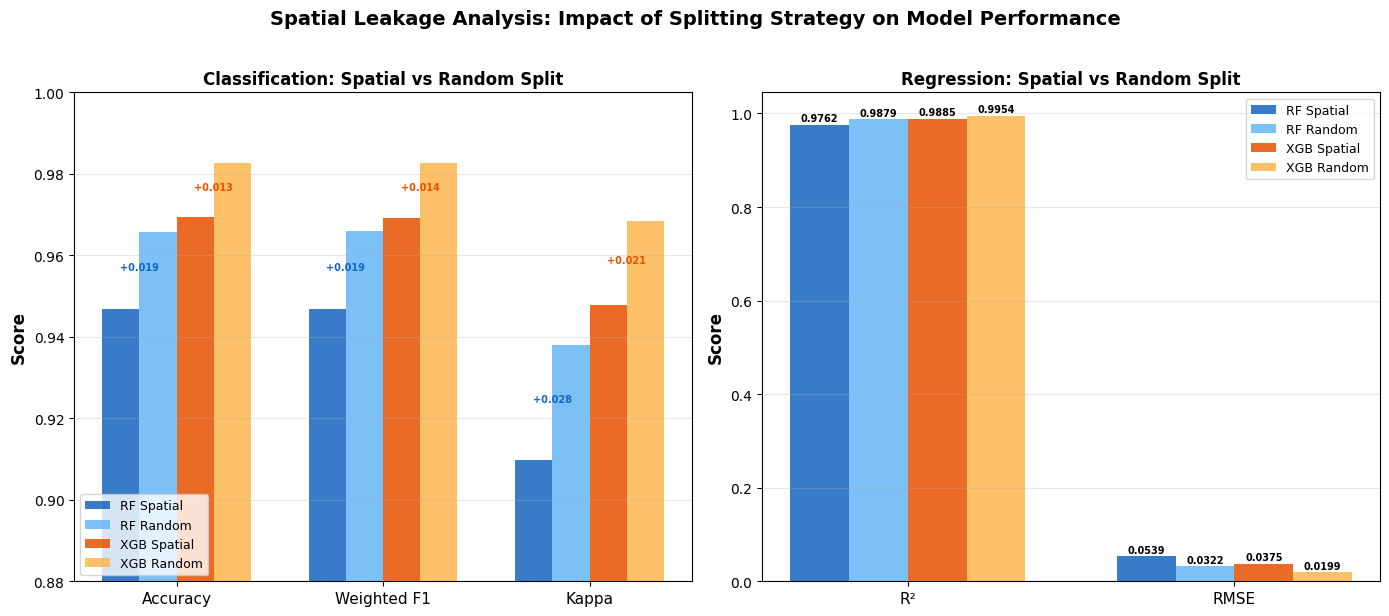

✓ Saved: viz5_spatial_leakage_comparison.png


In [20]:
# ---- SPATIAL vs RANDOM SPLIT COMPARISON ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT PANEL: Classification Metrics ----
ax1 = axes[0]

metrics = ["Accuracy", "Weighted F1", "Kappa"]
spatial_vals = [0.9468, 0.9469, 0.9097]   # RF spatial
random_vals = [0.9658, 0.9659, 0.9381]    # RF random
spatial_xgb = [0.9695, 0.9692, 0.9478]    # XGB spatial
random_xgb = [0.9827, 0.9827, 0.9684]     # XGB random

x = np.arange(len(metrics))
bar_width = 0.18

b1 = ax1.bar(x - 1.5*bar_width, spatial_vals, bar_width, label="RF Spatial", color="#1565C0", alpha=0.85)
b2 = ax1.bar(x - 0.5*bar_width, random_vals, bar_width, label="RF Random", color="#64B5F6", alpha=0.85)
b3 = ax1.bar(x + 0.5*bar_width, spatial_xgb, bar_width, label="XGB Spatial", color="#E65100", alpha=0.85)
b4 = ax1.bar(x + 1.5*bar_width, random_xgb, bar_width, label="XGB Random", color="#FFB74D", alpha=0.85)

# Add gap annotations
for i in range(3):
    rf_gap = random_vals[i] - spatial_vals[i]
    xgb_gap = random_xgb[i] - spatial_xgb[i]
    
    # RF gap arrow
    mid_rf = (spatial_vals[i] + random_vals[i]) / 2
    ax1.annotate(f"+{rf_gap:.3f}", xy=(x[i] - bar_width, mid_rf),
                fontsize=7, ha="center", color="#1565C0", fontweight="bold")
    
    # XGB gap arrow
    mid_xgb = (spatial_xgb[i] + random_xgb[i]) / 2
    ax1.annotate(f"+{xgb_gap:.3f}", xy=(x[i] + bar_width, mid_xgb),
                fontsize=7, ha="center", color="#E65100", fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylabel("Score", fontsize=12, fontweight="bold")
ax1.set_title("Classification: Spatial vs Random Split", fontsize=12, fontweight="bold")
ax1.set_ylim(0.88, 1.00)
ax1.legend(fontsize=9, loc="lower left")
ax1.grid(axis='y', alpha=0.3)

# ---- RIGHT PANEL: Regression Metrics ----
ax2 = axes[1]

reg_metrics = ["R²", "RMSE"]
rf_spatial_reg = [0.9762, 0.0539]
rf_random_reg = [0.9879, 0.0322]
xgb_spatial_reg = [0.9885, 0.0375]
xgb_random_reg = [0.9954, 0.0199]

# R² subplot
x2 = np.arange(len(reg_metrics))

b5 = ax2.bar(x2 - 1.5*bar_width, rf_spatial_reg, bar_width, label="RF Spatial", color="#1565C0", alpha=0.85)
b6 = ax2.bar(x2 - 0.5*bar_width, rf_random_reg, bar_width, label="RF Random", color="#64B5F6", alpha=0.85)
b7 = ax2.bar(x2 + 0.5*bar_width, xgb_spatial_reg, bar_width, label="XGB Spatial", color="#E65100", alpha=0.85)
b8 = ax2.bar(x2 + 1.5*bar_width, xgb_random_reg, bar_width, label="XGB Random", color="#FFB74D", alpha=0.85)

# Add value labels
for bars in [b5, b6, b7, b8]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.003,
                f"{height:.4f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

ax2.set_xticks(x2)
ax2.set_xticklabels(reg_metrics, fontsize=11)
ax2.set_ylabel("Score", fontsize=12, fontweight="bold")
ax2.set_title("Regression: Spatial vs Random Split", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(axis='y', alpha=0.3)

plt.suptitle("Spatial Leakage Analysis: Impact of Splitting Strategy on Model Performance",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "viz5_spatial_leakage_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: viz5_spatial_leakage_comparison.png")